1. Setup: Install & Import, Load Data
we install XGBoost, import all needed libraries, and load your CSV into a DataFrame.


 Dataset Snapshot:
   Chloraphylla ugL  DO mg  DO Sat  EC mScm     pH  Temp degC  Turbidity NTU
0              4.70  5.700   88.50   43.510  7.730     30.460           3.70
1              5.55  5.785   89.80   43.520  7.755     30.420           1.90
2              5.30  5.735   89.00   43.650  7.755     30.340           2.75
3              5.60  5.665   87.70   43.760  7.755     30.175           2.50
4              5.80  5.775   89.65   44.295  7.785     30.185           4.65

 Data Shape (rows, columns): (39958, 7)

 Column Names: ['Chloraphylla ugL', 'DO mg', 'DO Sat', 'EC mScm', 'pH', 'Temp degC', 'Turbidity NTU']

 Data Types:
Chloraphylla ugL    float64
DO mg               float64
DO Sat              float64
EC mScm             float64
pH                  float64
Temp degC           float64
Turbidity NTU       float64
dtype: object

 Missing Values Per Column:
Chloraphylla ugL    0
DO mg               0
DO Sat              0
EC mScm             0
pH                  0
Temp degC  

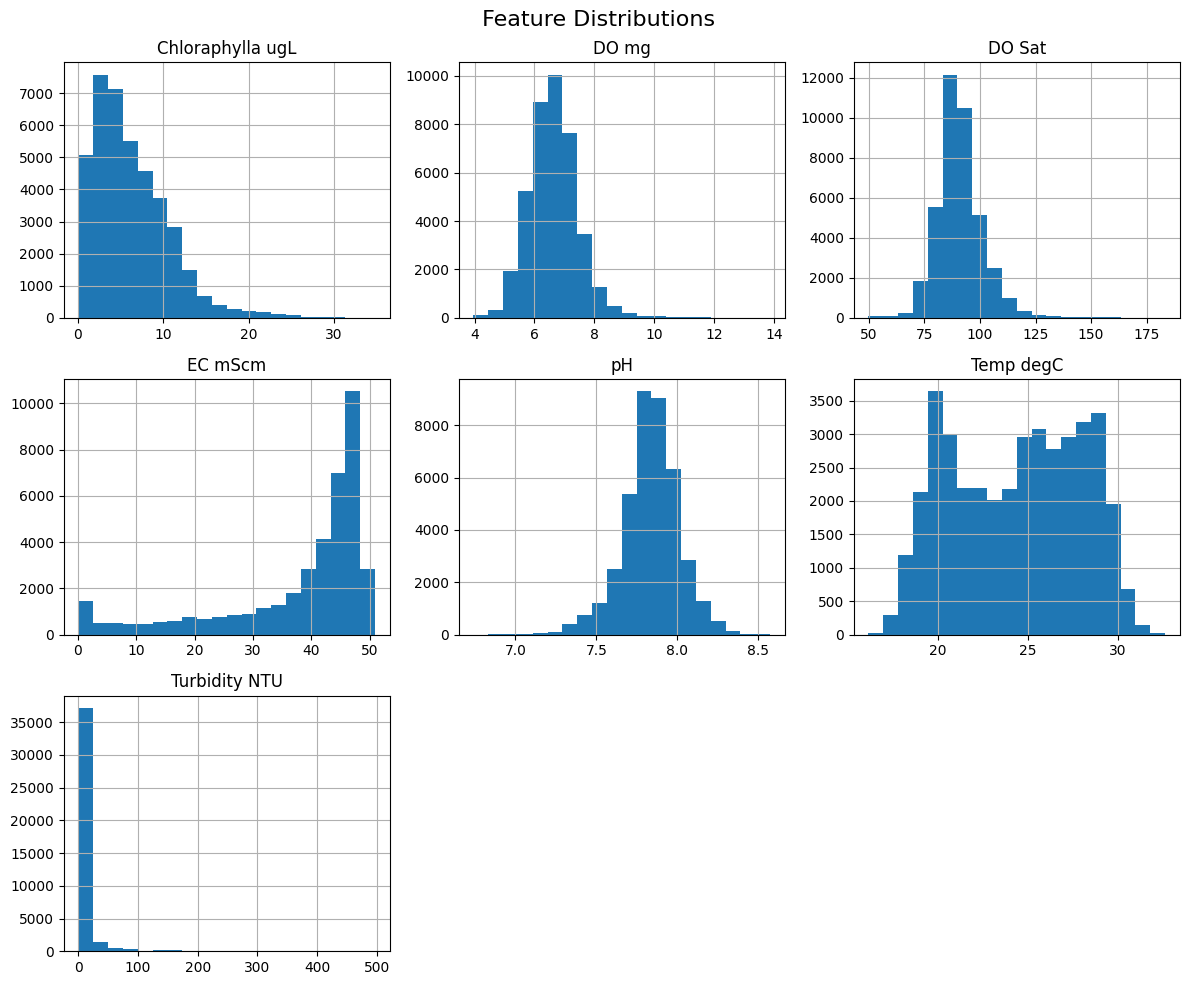

In [1]:
#!pip install xgboost --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Load dataset
df = pd.read_csv('/content/Hourly_data.csv')

# Preview structure and metadata
print("\n Dataset Snapshot:")
print(df.head())

print("\n Data Shape (rows, columns):", df.shape)
print("\n Column Names:", df.columns.tolist())
print("\n Data Types:")
print(df.dtypes)

# Check missing values
print("\n Missing Values Per Column:")
print(df.isnull().sum())

# Visualize distributions
df.hist(figsize=(12, 10), bins=20)
plt.suptitle(" Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

2. Exploratory Data Analysis (EDA) & Target Selection: inspect missing values, view basic stats, plot a correlation matrix, and choose the single most “predictable” feature (highest mean absolute correlation with others) as our target.

Missing values per column:
 Chloraphylla ugL    0
DO mg               0
DO Sat              0
EC mScm             0
pH                  0
Temp degC           0
Turbidity NTU       0
dtype: int64 



,Chloraphylla ugL,DO mg,DO Sat,EC mScm,pH,Temp degC,Turbidity NTU
count,39958.000000,39958.000000,39958.000000,39958.000000,39958.000000,39958.000000,39958.000000
mean,6.300544,6.648978,91.101502,37.817511,7.838370,24.367914,12.296035
std,4.386054,0.862679,10.987095,13.066689,0.175836,3.581589,25.350311
min,0.100000,3.960000,49.850000,0.087500,6.740000,16.150000,0.100000
25%,2.950000,6.095000,84.700000,33.970000,7.740000,20.995000,3.950000
50%,5.386980,6.605000,89.900000,43.510000,7.845000,24.715000,7.050000
75%,8.800000,7.120000,96.100000,46.695000,7.945000,27.500000,11.250000
max,34.800000,13.880000,183.300000,50.960000,8.575000,32.630000,497.250000


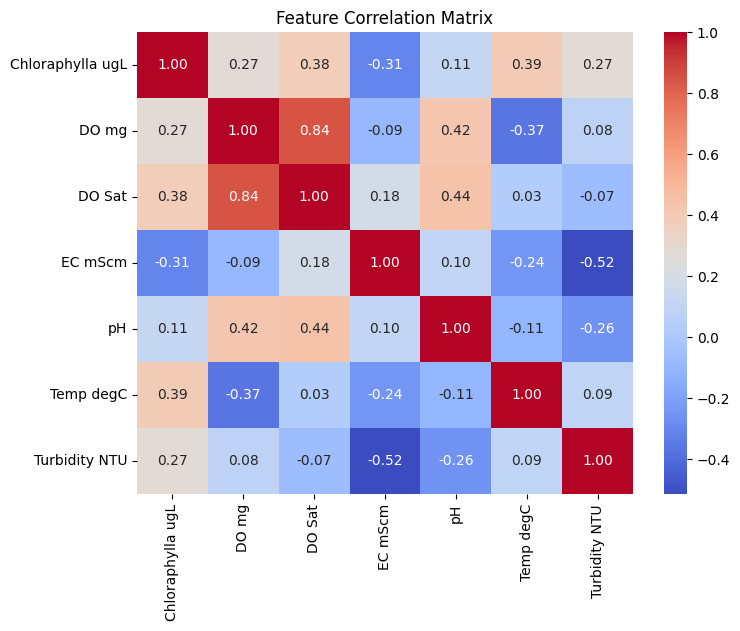

Chosen target (most correlated on average): 'DO Sat'


In [2]:
# 2.1 Check for missing values
print("Missing values per column:\n", df.isna().sum(), "\n")

# 2.2 Basic statistics
display(df.describe())

# 2.3 Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# 2.4 Pick the feature with highest avg |corr| to others (excluding self-corr=1)
corr = df.corr().abs()
avg_abs_corr = corr.mean().sort_values(ascending=False)
target = avg_abs_corr.index[1]
print(f"Chosen target (most correlated on average): '{target}'")


3. Data Preprocessing: we drop or impute missing rows, split into inputs (X) and output (y), do a train/test split, and scale features.

In [3]:
# 3.1 Features & target
X = df.drop(columns=[target])
y = df[target]

# 3.2 Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3.3 Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


4. Train & Evaluate Regression Models: we fit four regressors—Linear, Random Forest, SVR, and XGBoost—then compute Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²) on the test set.

In [5]:
# 4.1 Define models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR':              SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'XGBoost':          XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

from sklearn.linear_model import Ridge, Lasso

models['Ridge'] = Ridge(alpha=1.0)
models['Lasso'] = Lasso(alpha=0.1)

from lightgbm import LGBMRegressor
!pip install catboost
from catboost import CatBoostRegressor

models['LightGBM'] = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
models['CatBoost'] = CatBoostRegressor(verbose=0, n_estimators=100, learning_rate=0.1, random_state=42)

# 4.2 Train & evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}")

from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"{name} CV RMSE: {(-scores.mean())**0.5:.3f}")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00
LinearRegression: MAE=0.533, RMSE=0.826, R²=0.994
RandomForest: MAE=0.260, RMSE=0.489, R²=0.998
SVR: MAE=0.193, RMSE=1.144, R²=0.989
XGBoost: MAE=0.374, RMSE=0.648, R²=0.996
Ridge: MAE=0.533, RMSE=0.826, R²=0.994
Lasso: MAE=0.550, RMSE=0.860, R²=0.994
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1528
[LightGBM] [Info] Number of data points in the train set: 31966, number of used features: 6
[LightGBM] [Info] Start training from score 91.121783


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM: MAE=0.399, RMSE=0.666, R²=0.996
CatBoost: MAE=0.492, RMSE=0.792, R²=0.995
LinearRegression CV RMSE: 0.818
RandomForest CV RMSE: 0.509
SVR CV RMSE: 1.683
XGBoost CV RMSE: 0.700
Ridge CV RMSE: 0.818
Lasso CV RMSE: 0.855
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1527
[LightGBM] [Info] Number of data points in the train set: 25572, number of used features: 6
[LightGBM] [Info] Start training from score 91.109031


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001624 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1526
[LightGBM] [Info] Number of data points in the train set: 25573, number of used features: 6
[LightGBM] [Info] Start training from score 91.078188


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1528
[LightGBM] [Info] Number of data points in the train set: 25573, number of used features: 6
[LightGBM] [Info] Start training from score 91.129154


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1525
[LightGBM] [Info] Number of data points in the train set: 25573, number of used features: 6
[LightGBM] [Info] Start training from score 91.112150


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM CV RMSE: 0.670
CatBoost CV RMSE: 0.814


5. Compare Model Performance: we tabulate and plot the three metrics across the four models to see which performs best based on RMSE.

,MAE,RMSE,R2
RandomForest,0.259729,0.489273,0.997914
XGBoost,0.373726,0.647823,0.996343
LightGBM,0.398670,0.665927,0.996136
CatBoost,0.492370,0.791595,0.994540
Ridge,0.532937,0.825936,0.994056
LinearRegression,0.532940,0.825941,0.994056
Lasso,0.549664,0.859714,0.993560
SVR,0.192813,1.143968,0.988597


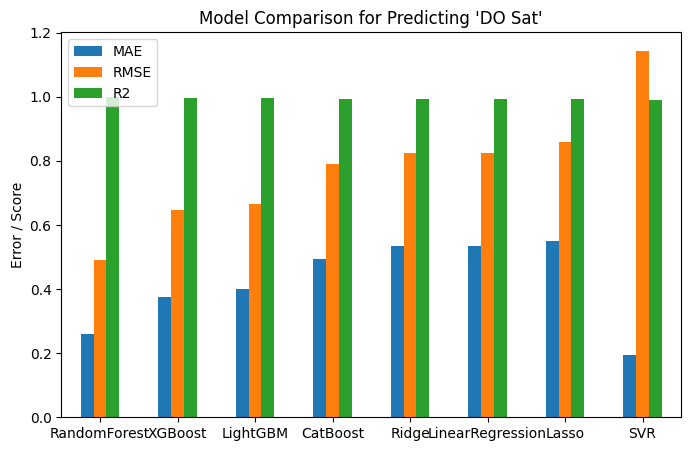

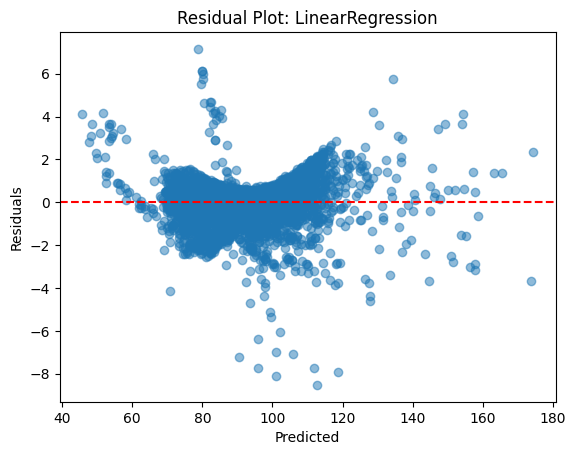

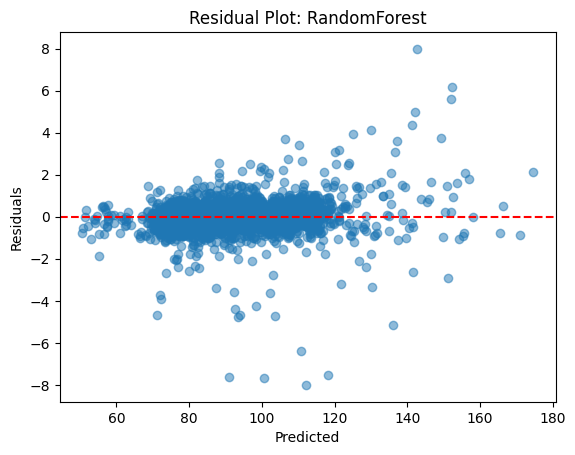

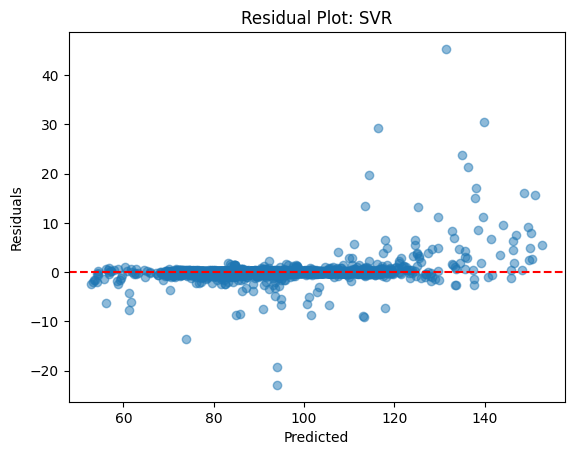

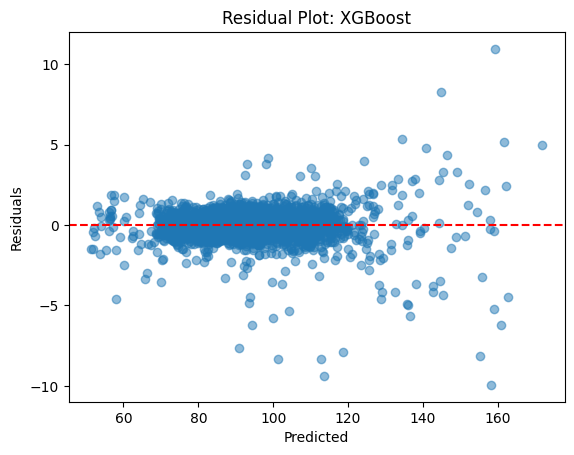

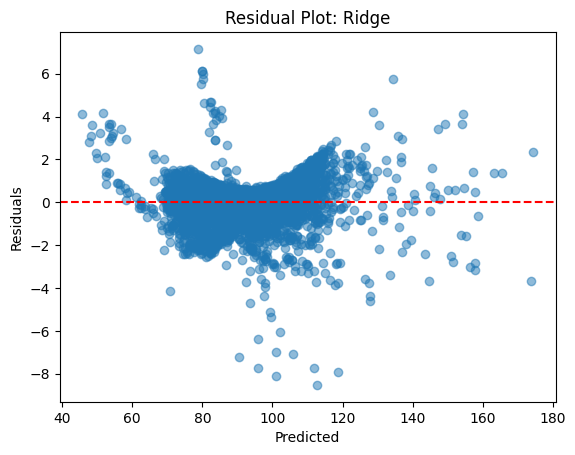

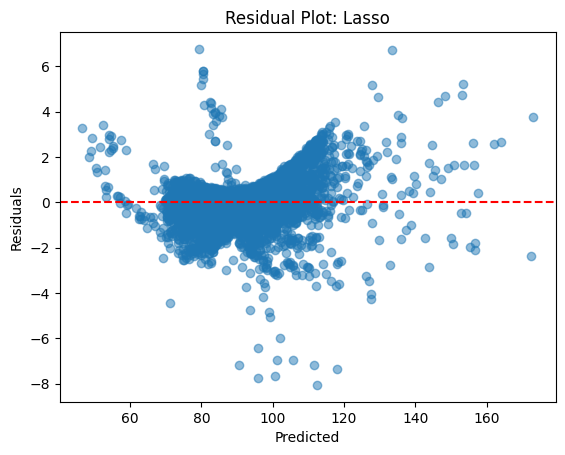

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


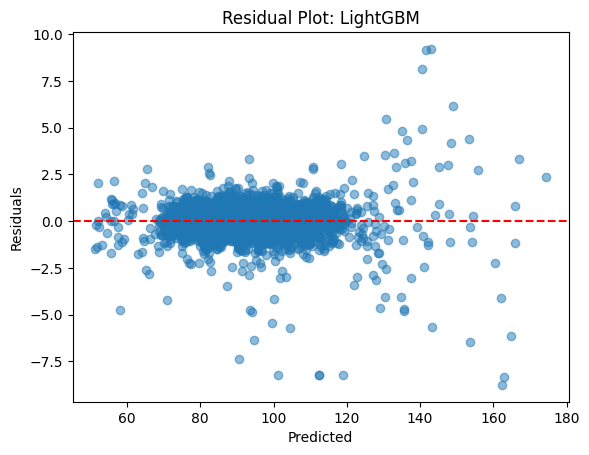

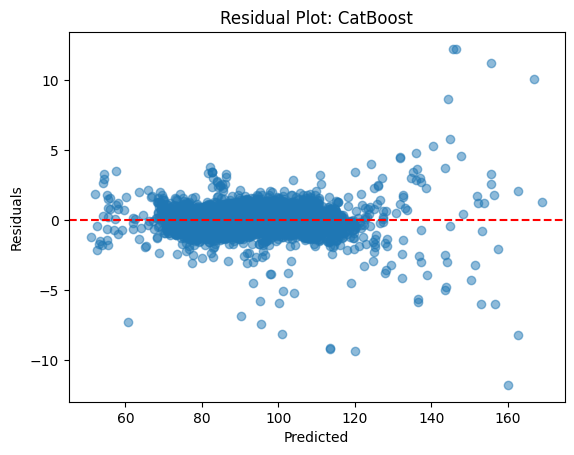

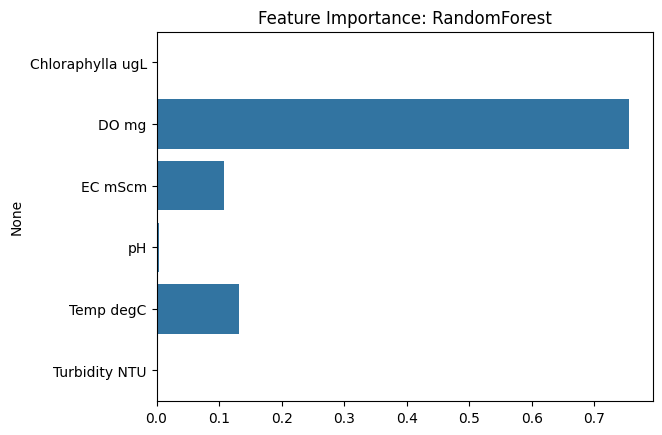

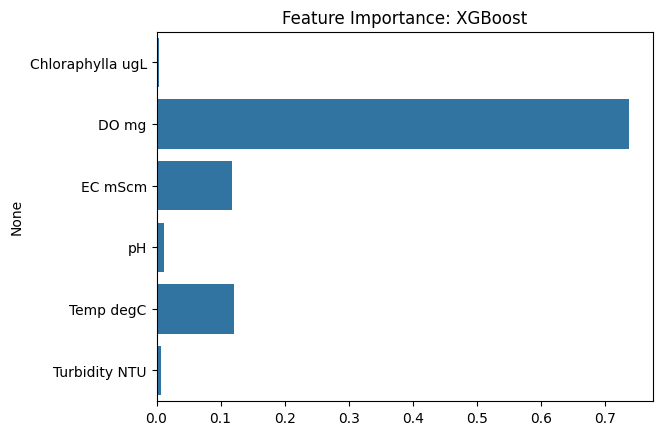

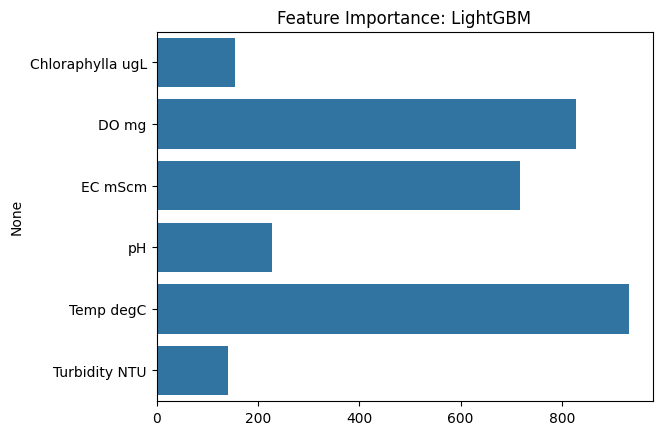

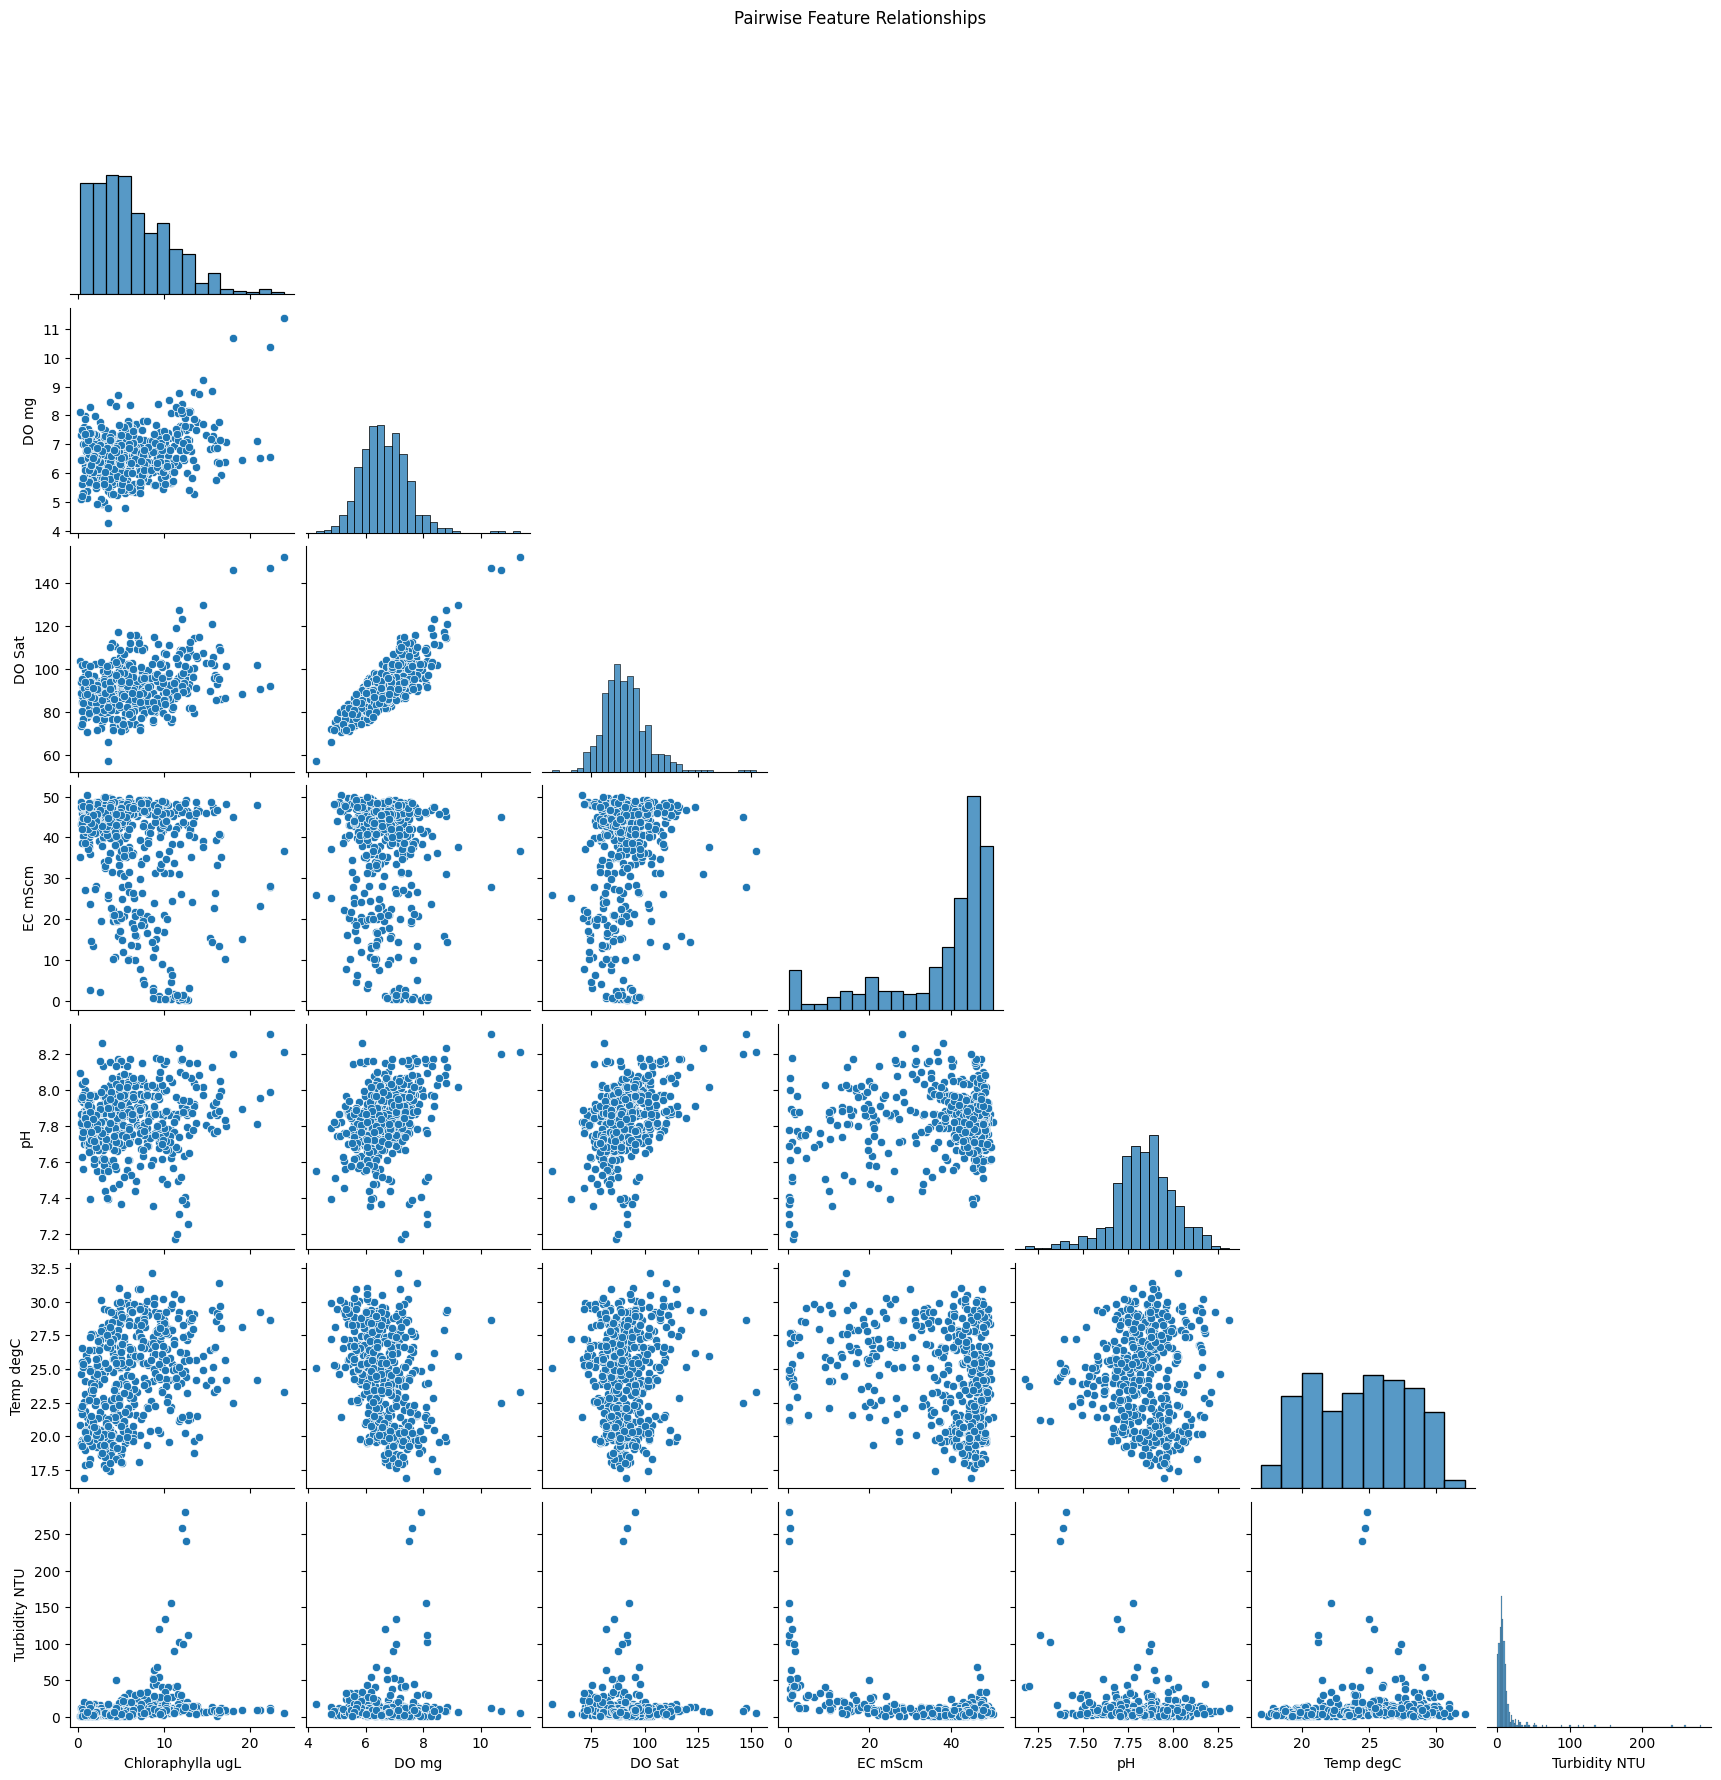

NameError: name 'best_model' is not defined

In [6]:
# 5.1 Results DataFrame
results_df = pd.DataFrame(results).T.sort_values('RMSE')
display(results_df)

# 5.2 Bar plot comparison
results_df.plot.bar(figsize=(8,5))
plt.title(f"Model Comparison for Predicting '{target}'")
plt.ylabel('Error / Score')
plt.xticks(rotation=0)
plt.show()

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    residuals = y_test - preds
    plt.scatter(preds, residuals, alpha=0.5)
    plt.title(f"Residual Plot: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.axhline(0, color='red', linestyle='--')
    plt.show()

for name in ['RandomForest', 'XGBoost', 'LightGBM']:
    if hasattr(models[name], 'feature_importances_'):
        imp = models[name].feature_importances_
        sns.barplot(x=imp, y=X.columns)
        plt.title(f"Feature Importance: {name}")
        plt.show()

sample_df = df.sample(500, random_state=42)
sns.pairplot(sample_df, corner=True)
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

preds = best_model.predict(X_test_scaled)
sns.kdeplot(y_test, label="True", shade=True)
sns.kdeplot(preds, label="Predicted", shade=True)
plt.legend()
plt.title(f"Distribution Comparison: {best_name}")
plt.show()



6. TinyML Prep: Measure Model Size & Latency: pick the best model by RMSE, pickle it to get its serialized size, and time its inference on a single sample to estimate CPU latency.

In [7]:
import pickle, os, time

# 6.1 Select best model
best_name = results_df.index[0]
best_model = models[best_name]
print(f"Best model: {best_name}")

# 6.2 Serialize & size
pkl_path = f"{best_name}.pkl"
with open(pkl_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Pickle size: {os.path.getsize(pkl_path)/1024:.1f} KB")

# 6.3 Inference latency (avg over 1,000 runs)
n_runs = 1000
sample = X_test_scaled[0:1]
start = time.time()
for _ in range(n_runs):
    best_model.predict(sample)
print(f"Avg sklearn inference: {(time.time()-start)/n_runs*1e3:.3f} ms/sample")


Best model: RandomForest
Pickle size: 266664.0 KB
Avg sklearn inference: 19.715 ms/sample


7. TinyML Conversion: Quantized TFLite: we build an equivalent simple Keras linear model, train it on the same data, then convert it with post-training quantization to a .tflite file and report its size.

In [8]:
import tensorflow as tf

# 7.1 Keras linear regressor
tf.random.set_seed(42)
keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1)
])
keras_model.compile(optimizer='adam', loss='mse')
keras_model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, verbose=0)

# 7.2 Convert with default quantization
converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# 7.3 Save and size
tflite_path = "model_quant.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"Quantized TFLite size: {os.path.getsize(tflite_path)/1024:.1f} KB")


Saved artifact at '/tmp/tmplbanttem'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136733248237456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136733248240720: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized TFLite size: 1.1 KB


8. TinyML On-Device, TFLite Inference Latency: load the .tflite into the TFLite interpreter, run the same sample 1,000 times, and report the average latency (ms/sample).

In [9]:
# 8.1 Setup interpreter
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp_detail = interpreter.get_input_details()[0]
out_detail = interpreter.get_output_details()[0]

# 8.2 Predict helper
def tflite_predict(x):
    interpreter.set_tensor(inp_detail['index'], x.astype(np.float32))
    interpreter.invoke()
    return interpreter.get_tensor(out_detail['index'])

# 8.3 Measure latency
start = time.time()
for _ in range(n_runs):
    tflite_predict(sample)
print(f"Avg TFLite inference: {(time.time()-start)/n_runs*1e3:.3f} ms/sample")


Avg TFLite inference: 0.007 ms/sample


_______________________________________________________________________________
The following code is a bit new to me and I am trying to understand better, so basically it was determeined that Random Forest was a better regressor than Linear Regression but keras only had Linear Regression available. So I searched online to find an equivalent for the Random Forests and found something called Yggdrasil Decision Forests and am still working on it further and trying to understand how to pipeline it to work on low capacity devices.

In [10]:
# 7.1 Install & import YDF
!pip install ydf -U --quiet

import ydf                    # Yggdrasil Decision Forests
import pandas as pd
import numpy as np
import time, os

# 7.2 Prepare your training DataFrame
train_df = pd.concat([X_train, y_train.rename(target)], axis=1)

# 7.3 Train a RandomForest for Regression
learner = ydf.RandomForestLearner(
    label=target,
    task=ydf.Task.REGRESSION,
    num_trees=100
)
model_ydf = learner.train(train_df)

# 7.4 Serialize & measure size
serialized = model_ydf.serialize()
print(f"Serialized YDF model size: {len(serialized)/1024:.1f} KB")

model_dir = "rf_ydf_model"
model_ydf.save(model_dir)
folder_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(model_dir)
    for f in files
)
print(f"Saved model directory size: {folder_size/1024:.1f} KB")

# 7.5 Benchmark inference latency
sample = X_test_scaled[0:1]
n_runs = 1000
start = time.time()
for _ in range(n_runs):
    _ = model_ydf.predict(pd.DataFrame(sample, columns=X.columns))
avg_ms = (time.time() - start) / n_runs * 1000
print(f"Avg YDF RF inference: {avg_ms:.3f} ms per sample")


Train model on 31966 examples
Model trained in 0:00:06.680954
Serialized YDF model size: 16997.9 KB
Saved model directory size: 44482.2 KB
Avg YDF RF inference: 1.745 ms per sample
